# Quantum Coherence in Ion Channels Using a Bose-Hubbard Hamiltonian Model in a Closed Quantum System

This notebook is authored by Lucas Nafe

# <u>Overview</u>

Quantum coherence is the ability of a quantum system to maintain a well-defined phase relationship between
different states in superposition. It allows qubits to perform complex calculations simultaneously and 
perserve their encoded information.


## <u>Standard Unitary Hamiltonian Evolution</u>

Standard unitary Hamiltonian evolution is built for closed and discrete quantum systems where energy and 
information are strictly conserved.

It is defined by:  $|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle$

The evolution operator is mathematically reversiible and the total probability always sums to 1 (normalized).
There is no friction, no thermal noise, and no settling into equilibrium, meaning it will bounce around the edges
of the simulation indefinitely, creating complex interference patterns. Because of this, you need to model
systems isolated from their environment: a closed quantum system.


## <u>The Biological Barrier</u>

Unlike modeling in the macroscopic, stochastic (random) arrival times of neurotransmitter molecules
reaching the end of an axon, which is driven by thermal noise, friction, and fluid dynamics, unitary
evolution cannot handle dissipation.

The brain is a "warm, wet, and noisy" environment, meaning quantum states usually collapse in
femtoseconds. 
Too put that into perspective:
* A femtosecond is $1e^-15$ seconds (one quadrillionth of a second)
* A femtosecond is to a second as a second is to about 37.71 million years
* A ray of light travels about 0.3 micrometers in one femtosecond

In order to combat this I have adopted the theoretical premise of quantum coherence in ion channels,
which preserves a closed quantum system before biological fluid and thermodynamics collapse
the quantum state.

## <u>Background Information</u>

In the brain, neurons communicate through chemical (neurotransmitters) and electrical (action potentials)
signals. Neurons fire action potentials by rapidly passing ions, like potassium ($K^+$), through
trans-membrane proteins called ion channels.

Voltage-gated ion channels are ion channels that open or close in response to changes in the membrane
potential (charge). These channels play a vital role in generation and propagation of electrical
signals in neurons. These primarily transport sodium ($Na^+$), potassium ($K^+$), calcium ($Ca^2+$), and
chlorine ($Cl^-$) ions.

The selectivity filter of a $K^+$ channel is incredibly narrow and transports ions at diffusion limits
with near-perfect accuracy, almost as if the classical energy barriers to entry don't exist. I will
model this process by treating the ions not as "billiard balls" passing through, but as measurable 
quantum-matter waves that undergo constructive interference to pass through the channel.


## <u>The Bose-Hubbard Hamiltonian</u>

The Bose-Hubbard Hamiltonian is the foundational math equation used to model how interacting quantum
particles move through a discrete lattice. It mathematically balances two competing forces: The desire
of particles to spread out as waves (kinetic energy) and the energetic penalty of particles bumping into
eachother (potential energy).


The standard form of the Bose-Hubbard Hamiltonian is:

$$H = -J \sum_{\langle i,j \rangle} \hat{b}_i^\dagger \hat{b}_j + \frac{U}{2} \sum_i \hat{n}_i (\hat{n}_i - 1) - \mu \sum_i \hat{n}_i$$


### The Hopping Term (Kinetic Energy):
$$-J \sum_{\langle i,j \rangle} \hat{b}_i^\dagger \hat{b}_j$$

* $J$: This controls how easily a particle can tunnel from one site to a neighboring site.
A higher J means particles are highly mobile and act more like delocalized quantum waves.

* $\hat{b}_i^\dagger \hat{b}_j$: This represents the creation and annihilation of a particle.
It is the quantum math for moving a particle as it mathematically "destroys" a particle, $\hat{b}_j$,
and at site $j$ and instantly "creates" a new particle, $\hat{b}_i^\dagger$, at the adjacent site $i$.

* ${\langle i,j \rangle}$: This notation means the sum only applies to nearest neighbors. A particle
cannot teleport across the whole lattice, it has to hop one step at a time.

### The Interaction Term (Potential Energy):
$$ \frac{U}{2} \sum_i \hat{n}_i (\hat{n}_i - 1)$$

* $U$: This represents on-site repulsion at each receptor. This is the energy penalty applied
when two or more particles try to occupy the same site.

* $\hat{n}_i (\hat{n}_i - 1)$: This is the number operator that simply counts the number of particles
sitting at site $i$.

* Why $\hat{n}_i (\hat{n}_i - 1)$? 
    * If a site has one particle, $\hat{n}_i (\hat{n}_i - 1) = 0$, so the energy penalty is zero and the
    particle doesn't repel itself.

    * If a site has 2 paricles the math spits out $1*U$, for 3 paricles the math spits out $3*U$, which
    represents a massive energy spike.

### The Chemical Potential:
$$ - \mu \sum_i \hat{n}_i$$

* $\mu$: This represents the chemical potential which acts as a global knob that controls the total number
of particles in the entire system. If you attach a lattice to a reservior of particles, a high $\mu$ will 
pull more particles into the lattice.


## <u>Quantum Phase Transition</u>

The Bose-Hubbard Hamiltonian model lies in the ratio between $J$ (movement) and $U$ (Repulsion). By tweaking
this ratio, the system undergoes a quantum phase transition between the Superfluid phase and the Mott Insulator Phase.

### The Superfluid Phase ($J$ > $U$)
If moving from site-to-site is easy and repulsion is weak, the particles are delocalized and act as one coherent quantum wave. 
They spread out across the entire lattice, and you cannot pinpoint where any individual particle is. This is what you want
for an efficient ion channel.

### The Mott Insulator Phase ($J$ < $U$)
If the repulsion penalty is large, the particles become extremely resistent to occupying the same site. If there is 
exactly one particle per site, they will completely lock into place, forming a rigid, non-moving grid.
The quantum wave function collapses into distinct, localized particles, representing a clogged ion channel.







## <u>Objectives</u>

The goal of my experiments to develop a quantum algorithm derived from the Bose-Hubbard Hamiltonian that can be used to create a closed quantum system to simulate the system within the slim "coherence" time window before the biological fluid collapses the quantum state. 

## <u>The Quantum Algorithm</u>

Apply an X gate &rarr; *Trotter product* [Apply a SWAP gate &rarr; Apply a RZ gate] $*$ $N$ steps &rarr; Measure

### The X Gate
We want to start with particles actually existing in our lattice. A qubit in state $|0\rangle$ means an empty site. Applying an X gate to specific qubits to flip them to $|1\rangle$ initializes a particle dropped onto that specific site.

### The Trotter Product
Because the particles are simultaneously trying to hop and experiencing potential energy, we chop time into tiny slices ($\Delta t$) and apply SWAP and RZ gates, repeating them $N$ times.

#### The SWAP Gate
The particle probability wave moves left and right into neighboring sites. We apply a SWAP gate across pairs of adjacent qubits. If the pair is $|01\rangle$ (particle on the right), the gate partially rotates it into $|10\rangle$ (particle on the left), creating a quantum superposition of the particle being in both places.

#### The RZ Gate
The particles accumulate a quantum phase (energy) based on which site they are sitting on. Apply an RZ gate (Phase rotation around the Z-axis) to every single qubit. If the qubit is $|0\rangle$ (empty), nothing happens. If the qubit is $|1\rangle$ (occupied), its phase is rotated by an amount proportional to the site's energy ($\mu \times \Delta t$).

### Measurment
We can meausure the quantum state to see where the particles ended up. Doing this collapses the smooth, wave-like superposition into concrete particle locations. To do this we measure every qubit in the standard computational basis (Z-basis) to get a readable string of 1s and 0s.

## Simulating Simple Superfluid Phase

Probability of particle present at Site 0: 0.434023962772594
Probability of particle present at Site 1: 0.5056861217166337
Probability of particle present at Site 2: 0.4345943977502263
Probability of particle present at Site 3: 0.20863218078350565
Probability of particle present at Site 4: 0.4170633369770576


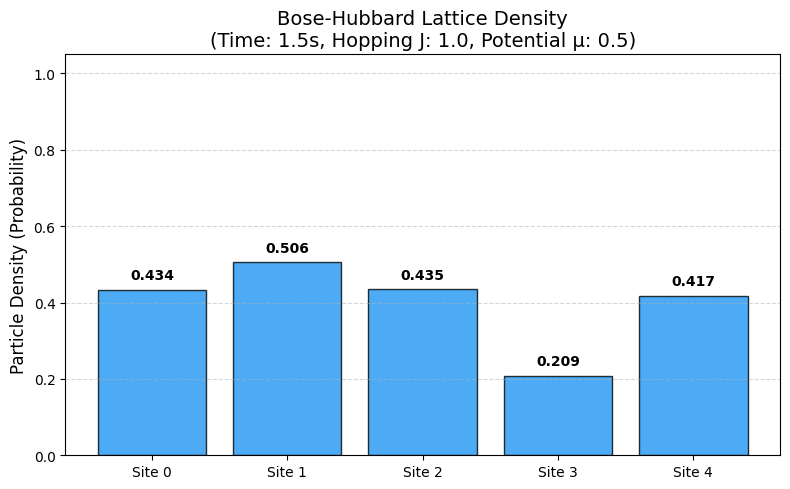

In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Define Lattice 
num_sites = 5
dev = qml.device('default.qubit', wires=num_sites)

# Physics Parameters
J = 1.0      # Hopping strength (Kinetic energy)
mu = 0.5     # Chemical potential (Site energy)
time = 1.5   # Total simulation time
steps = 20   # Number of Trotter steps
dt = time / steps # Time chunk per step

@qml.qnode(dev)
def bose_hubbard_circuit(J, mu, dt, steps):
    # State Preparation --> place particles on the lattice at Site 0 and 2
    qml.PauliX(wires=0)
    qml.PauliX(wires=2)
    
    # Trotterized Time Evolution
    for step in range(steps):
        
        # The Hopping Term
        for i in range(num_sites - 1):
            # The IsingXY (SWAP) gate naturally swaps |01> and |10> states
            # This represents a particle tunneling left or right
            qml.IsingXY(2 * J * dt, wires=[i, i+1])
            
        # The Potential Term
        for i in range(num_sites):
            # The RZ gate applies the local energy phase based on occupancy
            qml.RZ(mu * dt, wires=i)
            
    # Measurement: Find the expected particle density at each site
    # A qubit in |1> means 1 particle, |0> means 0 particles.
    # qml.Projector to directly measure the probability of finding a '1'
    return [qml.expval(qml.Projector([1], wires=i)) for i in range(num_sites)]


# Run simulation
densities = bose_hubbard_circuit(J, mu, dt, steps)

for site, density in enumerate(densities):
    print(f"Probability of particle present at Site {site}: {density}")


sites = [f"Site {i}" for i in range(num_sites)]


# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(sites, densities, color='#2196F3', edgecolor='black', alpha=0.8)

# Formatting
plt.ylim(0, 1.05) # Probabilities max out at 1.0
plt.ylabel('Particle Density (Probability)', fontsize=12)
plt.title(f'Bose-Hubbard Lattice Density\n(Time: {time}s, Hopping J: {J}, Potential μ: {mu})', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact probability numbers on top of each bar
for bar, density in zip(bars, densities):
    plt.text(bar.get_x() + bar.get_width()/2, 
             density + 0.02, 
             f'{density:.3f}', 
             ha='center', va='bottom', fontweight='bold')

# Display
plt.tight_layout()
plt.show()

### Discussion of Results

This simulation models particle transport in a simplified Bose–Hubbard model lattice, where particles initially placed at Sites 0 and 2 spread across neighboring sites over time due to the hopping interaction ($J$). The resulting bar chart shows the probability of finding a particle at each lattice site after the Trotterized time evolution with a 43.3% chance of seeing a particle at site 0, a 50.6% chance of seeing a particle at site 1, a 43.5% chance of seeing a particle at site 2, a 20.9% chance of seeing a particle at site 3, and a 41.7% chance of seeing a particle at site 4. This illustrates how quantum tunneling redistributes particle density throughout the lattice. Differences in the final probabilities reflect the competition between particle hopping and the local potential energy, $\mu$.


## Simulating Full Bose-Hubbard Hamiltonian in Ion Channel

Probabilities of Superfluid Phase: [0.         0.         0.49396813 0.         0.         0.40141927
 0.         0.         0.10461261 0.         0.         0.
 0.         0.         0.         0.        ]
Probabilities of Mott Insulator Phase: [0.         0.         0.00321863 0.         0.         0.0114546
 0.         0.         0.98532677 0.         0.         0.
 0.         0.         0.         0.        ]


Testing Superfluid Phase vs. Mott Insulator Phase:


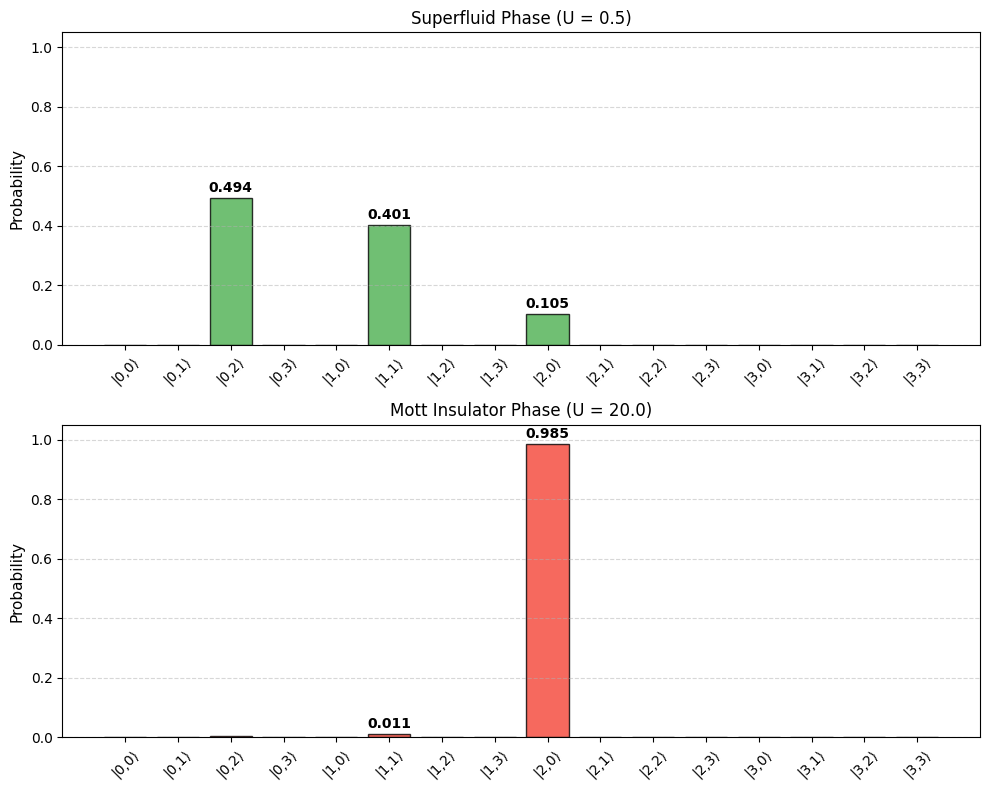

In [52]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

#System Setup
num_sites = 2
qubits_per_site = 2 
total_qubits = num_sites * qubits_per_site

dev = qml.device('default.qubit', wires=total_qubits)

#Build Hamiltonian matrices
b_dag = np.zeros((4, 4))
b_dag[1, 0] = np.sqrt(1)
b_dag[2, 1] = np.sqrt(2)
b_dag[3, 2] = np.sqrt(3)

b_down = b_dag.T

# The Hopping Matrix for 2 sites (Tensor product creating a 16x16 matrix)
# (b_1^dagger * b_2) + (b_1 * b_2^dagger)
hopping_matrix = np.kron(b_dag, b_down) + np.kron(b_down, b_dag)


# Define Quantum Gates
def hopping_gate(J, dt, wires):
    U_hop = scipy.linalg.expm(1j * J * dt * hopping_matrix)
    qml.QubitUnitary(U_hop, wires=wires)

def interaction_gate(U_int, mu, dt, wires):
    energies = np.array([0, -mu, U_int - 2*mu, 3*U_int - 3*mu]) # n = 0,1,2,3 respectively
    U_diag = np.exp(-1j * energies * dt)
    qml.DiagonalQubitUnitary(U_diag, wires=wires)


# The Quantum Circut
@qml.qnode(dev)
def bose_hubbard_circuit(J, U_int, mu, dt, steps):
    # Initial State: |1000> --> 2 particles on Site 0 and none on Site 1
    qml.PauliX(wires=0) 

    for step in range(steps):
        hopping_gate(J, dt, wires=[0, 1, 2, 3])
        interaction_gate(U_int, mu, dt, wires=[0, 1])
        interaction_gate(U_int, mu, dt, wires=[2, 3])
        
    return qml.probs(wires=[0, 1, 2, 3]) #return probabilities as numpy array

# Parameters for Simulation
J = 1.0
mu = 0.0
dt = 0.1
steps = 10


# Run Simulation


probs_sf = bose_hubbard_circuit(J, U_int=0.5, mu=mu, dt=dt, steps=steps)
# In this phase, the particles easily wave-spread to Site 1

probs_mott = bose_hubbard_circuit(J, U_int=20.0, mu=mu, dt=dt, steps=steps)
# In this phase, the high energy penalty U prevents particles from moving
# They stay locked on Site 0


#Display Probabilities
print(f"Probabilities of Superfluid Phase: {probs_sf}")
print(f"Probabilities of Mott Insulator Phase: {probs_mott}")
print("\n\nTesting Superfluid Phase vs. Mott Insulator Phase:")

# Create readable labels for all 16 states (|n0, n1⟩)
labels = []
for i in range(16):
    binary = format(i, "04b")
    n0 = int(binary[0:2], 2)
    n1 = int(binary[2:4], 2)
    labels.append(f"|{n0},{n1}⟩")


# Set up the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Superfluid Phase Plot
ax1.bar(labels, probs_sf, color="#4CAF50", edgecolor="black", alpha=0.8)
ax1.set_title(f"Superfluid Phase (U = 0.5)", fontsize=12)
ax1.set_ylabel("Probability", fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate non-zero probabilities
for i, prob in enumerate(probs_sf):
    if prob > 0.01:
        ax1.text(i, prob + 0.02, f'{prob:.3f}', ha="center", fontweight="bold")

# Mott Insulator Phase Plot
ax2.bar(labels, probs_mott, color="#F44336", edgecolor="black", alpha=0.8)
ax2.set_title(f"Mott Insulator Phase (U = 20.0)", fontsize=12)
ax2.set_ylabel("Probability", fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate non-zero probabilities
for i, prob in enumerate(probs_mott):
    if prob > 0.01:
        ax2.text(i, prob + 0.02, f'{prob:.3f}', ha="center", fontweight="bold")

# Display
plt.tight_layout()
plt.show()

### Discussion

Because this model strictly conserves the total number of particles (we started with 2, and they can't be created or destroyed, just moved), you will notice that out of the 16 bars on the chart, only 3 will ever have a probability greater than zero:

|2,0⟩: Both particles stayed on the left site.

|1,1⟩: One particle hopped to the right site.

|0,2⟩: Both particles hopped to the right site.

This simulation compares two phases of the Bose–Hubbard model by varying the interaction strength, $U$. In the superfluid phase $U=0.5$, the particles are able to tunnel between the two lattice sites, so the probability distribution spreads across multiple states with probabilities of both particles being at site 0 at 10.5%, one particle moving to site 1 at 40.1%, and both particles moving to site 1 at 49.4%, indicating particle delocalization and coherent quantum motion. In contrast, the Mott insulator phase $U=20$, strongly suppresses hopping because of the large interaction energy penalty, causing the particles to remain localized on their original site with a probability of both particles in the initial state at Site 0 at 98.5%.


## Interactive Visualizer of Bose-Hubbard Model and Ion Channel

In [ ]:
from IPython.display import HTML, display
import html

# The Bose-Hubbard Visualizer
bose_hubbard_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Bose-Hubbard Phase Transition</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #fdfbf7; color: #333; margin: 0; padding: 20px; display: flex; flex-direction: column; align-items: center; }
        .container { max-width: 800px; width: 100%; background: white; padding: 20px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center; }
        h1 { font-size: 1.5em; margin-top: 0; color: #2c3e50; }
        .controls { margin-bottom: 20px; padding: 15px; background: #f4f4f4; border-radius: 8px; display: flex; flex-direction: column; align-items: center; gap: 10px; }
        label { font-weight: bold; font-size: 1.1em; }
        input[type=range] { width: 80%; max-width: 400px; }
        .status { font-size: 1.2em; font-weight: bold; color: #0d47a1; margin-top: 10px; padding: 10px; background: #e3f2fd; border-radius: 4px; display: inline-block; }
        canvas { background: #fafafa; border: 1px solid #ddd; border-radius: 8px; max-width: 100%; box-shadow: inset 0 0 10px rgba(0,0,0,0.05); }
        .explanation { text-align: left; margin-top: 20px; font-size: 0.9em; color: #555; line-height: 1.5; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Bose-Hubbard Phase Transition</h1>
        
        <div class="controls">
            <label for="ujRatio">Ratio of U/J: <span id="uj-val">10.0</span></label>
            <input type="range" id="ujRatio" min="0.1" max="20" step="0.1" value="10">
            <div class="status" id="stateText">Current State: Mott Insulator</div>
        </div>

        <canvas id="latticeCanvas" width="760" height="300"></canvas>
    </div>

    <script>
        const canvas = document.getElementById('latticeCanvas');
        const ctx = canvas.getContext('2d');
        const slider = document.getElementById('ujRatio');
        const ujValText = document.getElementById('uj-val');
        const stateText = document.getElementById('stateText');
        
        const numWells = 8;
        const width = canvas.width;
        const height = canvas.height;
        const wellWidth = width / numWells;

        function drawLattice(time) {
            ctx.clearRect(0, 0, width, height);
            let uj = parseFloat(slider.value);
            
            ctx.beginPath();
            ctx.lineWidth = 3;
            ctx.strokeStyle = '#9e9e9e';
            for(let x = 0; x <= width; x++) {
                let normalizedX = (x % wellWidth) / wellWidth; 
                let y = height / 2 + Math.cos(normalizedX * Math.PI * 2 + Math.PI) * 40;
                if(x === 0) ctx.moveTo(x, y);
                else ctx.lineTo(x, y);
            }
            ctx.stroke();

            let delocalization = 1 - Math.min(Math.max((uj - 1) / 9, 0), 1); 
            
            for(let i = 0; i < numWells; i++) {
                let cx = wellWidth * (i + 0.5);
                let cy = height / 2 + 30; 
                let baseRadius = 15;
                let spread = baseRadius + delocalization * (wellWidth * 1.5); 
                let flutter = delocalization * Math.sin(time * 4 + i * 2.1) * (wellWidth * 0.3);
                let currentSpread = Math.max(baseRadius, spread + flutter);
                let alpha = 0.9 - delocalization * 0.75;
                
                let gradient = ctx.createRadialGradient(cx, cy, 0, cx, cy, currentSpread);
                gradient.addColorStop(0, `rgba(33, 150, 243, ${alpha})`);
                gradient.addColorStop(0.5, `rgba(33, 150, 243, ${alpha * 0.5})`);
                gradient.addColorStop(1, `rgba(33, 150, 243, 0)`);
                
                ctx.fillStyle = gradient;
                ctx.beginPath();
                ctx.arc(cx, cy, currentSpread, 0, Math.PI * 2);
                ctx.fill();
            }
        }

        function animate(timestamp) {
            let time = timestamp / 1000;
            drawLattice(time);
            requestAnimationFrame(animate);
        }

        slider.addEventListener('input', (e) => {
            let val = parseFloat(e.target.value);
            ujValText.innerText = val.toFixed(1);
            if (val > 5) {
                stateText.innerText = "Current State: Mott Insulator";
                stateText.style.color = "#d32f2f";
                stateText.style.backgroundColor = "#ffebee";
            } else {
                stateText.innerText = "Current State: Superfluid";
                stateText.style.color = "#1976d2";
                stateText.style.backgroundColor = "#e3f2fd";
            }
        });

        slider.dispatchEvent(new Event('input'));
        requestAnimationFrame(animate);
    </script>
</body>
</html>
"""

# The Ion Channel Visualizer
ion_channel_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Quantum Coherence in Ion Channels</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #fdfbf7; color: #333; margin: 0; padding: 20px; display: flex; flex-direction: column; align-items: center; }
        .container { max-width: 800px; width: 100%; background: white; padding: 20px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
        h1 { font-size: 1.5em; text-align: center; margin-top: 0; color: #2c3e50; }
        .controls { display: flex; flex-wrap: wrap; gap: 15px; margin-bottom: 20px; padding: 15px; background: #f4f4f4; border-radius: 8px; justify-content: space-between; align-items: center; }
        .control-group { display: flex; flex-direction: column; flex: 1; min-width: 150px; }
        label { font-weight: bold; margin-bottom: 5px; font-size: 0.9em; }
        .btn-group { display: flex; gap: 10px; }
        button { padding: 8px 16px; font-size: 1em; border: none; border-radius: 4px; cursor: pointer; background: #2196F3; color: white; font-weight: bold; }
        button.pause { background: #FF9800; }
        button.reset { background: #f44336; }
        .visualizer { position: relative; width: 100%; height: 200px; background: #fafafa; border: 1px solid #ddd; border-radius: 8px; margin-bottom: 20px; display: flex; justify-content: center; align-items: center; }
        canvas { display: block; }
        .chart-container { position: relative; height: 250px; width: 100%; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Ion Channel Simulator</h1>
        
        <div class="controls">
            <div class="control-group">
                <label for="hopping">Hopping Strength (J): <span id="hopping-val">1.0</span></label>
                <input type="range" id="hopping" min="0.1" max="5.0" step="0.1" value="1.0">
            </div>
            <div class="control-group">
                <label for="speed">Simulation Speed: <span id="speed-val">1.0x</span></label>
                <input type="range" id="speed" min="0.1" max="3.0" step="0.1" value="1.0">
            </div>
            <div class="btn-group">
                <button id="playPauseBtn">Pause</button>
                <button id="resetBtn" class="reset">Reset</button>
            </div>
        </div>

        <div class="visualizer">
            <canvas id="latticeCanvas" width="760" height="200"></canvas>
        </div>

        <div class="chart-container">
            <canvas id="probChart"></canvas>
        </div>
    </div>

    <script>
        let numSites = 5;
        let state = [];
        let isPlaying = true;
        let lastTime = 0;
        
        function initState() {
            state = [];
            for(let i=0; i<numSites; i++) {
                state.push({ r: i === 0 ? 1 : 0, i: 0 }); 
            }
        }
        initState();

        const hoppingSlider = document.getElementById('hopping');
        const speedSlider = document.getElementById('speed');
        const playPauseBtn = document.getElementById('playPauseBtn');
        const resetBtn = document.getElementById('resetBtn');
        const latticeCanvas = document.getElementById('latticeCanvas');
        const ctxLattice = latticeCanvas.getContext('2d');
        const ctxChart = document.getElementById('probChart').getContext('2d');
        
        const probChart = new Chart(ctxChart, {
            type: 'bar',
            data: {
                labels: ['Site 1', 'Site 2', 'Site 3', 'Site 4', 'Site 5'],
                datasets: [{
                    label: 'Probability |ψ|²',
                    data: [1, 0, 0, 0, 0],
                    backgroundColor: 'rgba(33, 150, 243, 0.7)',
                    borderColor: 'rgba(33, 150, 243, 1)',
                    borderWidth: 1
                }]
            },
            options: {
                responsive: true, maintainAspectRatio: false, animation: false,
                scales: { y: { beginAtZero: true, max: 1.0 } }
            }
        });

        hoppingSlider.addEventListener('input', (e) => document.getElementById('hopping-val').innerText = e.target.value);
        speedSlider.addEventListener('input', (e) => document.getElementById('speed-val').innerText = e.target.value + 'x');
        
        playPauseBtn.addEventListener('click', () => {
            isPlaying = !isPlaying;
            playPauseBtn.innerText = isPlaying ? 'Pause' : 'Play';
            if(isPlaying) requestAnimationFrame(loop);
        });

        resetBtn.addEventListener('click', () => {
            initState();
            drawLattice();
            updateChart();
            if(!isPlaying) {
                isPlaying = true;
                playPauseBtn.innerText = 'Pause';
                lastTime = performance.now();
                requestAnimationFrame(loop);
            }
        });

        function evolve(dt) {
            const J = parseFloat(hoppingSlider.value);
            const substeps = 10;
            const h = dt / substeps;
            
            for(let s=0; s<substeps; s++) {
                let dState = [];
                for(let n=0; n<numSites; n++) {
                    let r_prev = (n > 0) ? state[n-1].r : 0;
                    let i_prev = (n > 0) ? state[n-1].i : 0;
                    let r_next = (n < numSites-1) ? state[n+1].r : 0;
                    let i_next = (n < numSites-1) ? state[n+1].i : 0;
                    dState.push({ r: -J * (i_prev + i_next), i: J * (r_prev + r_next) });
                }
                let norm = 0;
                for(let n=0; n<numSites; n++) {
                    state[n].r += dState[n].r * h;
                    state[n].i += dState[n].i * h;
                    norm += state[n].r**2 + state[n].i**2;
                }
                norm = Math.sqrt(norm);
                for(let n=0; n<numSites; n++) {
                    state[n].r /= norm;
                    state[n].i /= norm;
                }
            }
        }

        function drawLattice() {
            ctxLattice.clearRect(0, 0, latticeCanvas.width, latticeCanvas.height);
            const padding = 150;
            const spacing = (latticeCanvas.width - 2 * padding) / (numSites - 1);
            const cy = latticeCanvas.height / 2;

            ctxLattice.beginPath();
            ctxLattice.moveTo(padding, cy);
            ctxLattice.lineTo(latticeCanvas.width - padding, cy);
            ctxLattice.strokeStyle = '#ccc';
            ctxLattice.lineWidth = 4;
            ctxLattice.stroke();

            for(let i=0; i<numSites; i++) {
                const cx = padding + i * spacing;
                const prob = state[i].r**2 + state[i].i**2;
                
                ctxLattice.beginPath();
                ctxLattice.arc(cx, cy, 25, 0, 2 * Math.PI);
                ctxLattice.fillStyle = '#fff';
                ctxLattice.fill();
                ctxLattice.lineWidth = 3;
                ctxLattice.strokeStyle = '#2196F3';
                ctxLattice.stroke();

                if (prob > 0.01) {
                    ctxLattice.beginPath();
                    ctxLattice.arc(cx, cy, 20 * prob + 5, 0, 2 * Math.PI);
                    ctxLattice.fillStyle = `rgba(33, 150, 243, ${prob + 0.2})`;
                    ctxLattice.fill();
                }
            }
        }

        function updateChart() {
            let probs = state.map(s => s.r**2 + s.i**2);
            probChart.data.datasets[0].data = probs;
            probChart.update();
        }

        function loop(timestamp) {
            if (!isPlaying) return;
            if (!lastTime) lastTime = timestamp;
            let dt = (timestamp - lastTime) / 1000; 
            lastTime = timestamp;
            if(dt > 0.1) dt = 0.1; 

            evolve(dt * parseFloat(speedSlider.value));
            drawLattice();
            updateChart();
            requestAnimationFrame(loop);
        }

        requestAnimationFrame((t) => { lastTime = t; loop(t); });
    </script>
</body>
</html>
"""

# Escape HTML and Build the Side-by-Side Dashboard
safe_bose = html.escape(bose_hubbard_html)
safe_ion = html.escape(ion_channel_html)

# Utilize CSS Flexbox to split the available width 50/50 and place them next to each other
dashboard_html = f"""
<div style="display: flex; flex-direction: row; justify-content: space-between; align-items: flex-start; gap: 15px; width: 100%;">
    <div style="flex: 1; min-width: 0;">
        <h3 style="text-align: center; font-family: sans-serif; color: #FFFFFF;">Bose-Hubbard Visualizer</h3>
        <iframe srcdoc="{safe_bose}" style="width: 100%; height: 750px; border: 1px solid #ccc; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);" sandbox="allow-scripts allow-same-origin"></iframe>
    </div>
    <div style="flex: 1; min-width: 0;">
        <h3 style="text-align: center; font-family: sans-serif; color: #FFFFFF;">Ion Channel Visualizer</h3>
        <iframe srcdoc="{safe_ion}" style="width: 100%; height: 750px; border: 1px solid #ccc; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);" sandbox="allow-scripts allow-same-origin"></iframe>
    </div>
</div>
"""

# Display
display(HTML(dashboard_html))

* These interactive visual representations of the quantum lattice I have built as well as the quantum phase transitions that took place in both of my simulations are viewable in README.md.

## AI Collaboration

* Helping decipher terms within Bose-Hubbard Hamiltonian model

* Helping create interactive visualizers

* Organization and formating

* Helping generate ideas for direction of my project
    * Landed me on quantum coherence in ion channels

## Conclusion and Future Discussion

In this project, I used quantum simulation techniques in Python with PennyLane to model quantum coherence in ion channels with a simplified Bose–Hubbard lattice system. The simulation applied Trotterized time evolution with hopping and potential terms to study how particles move and distribute themselves across a five-site lattice over time. The results demonstrated that particles initially localized at specific lattice sites spread throughout the system due to quantum tunneling, producing measurable probability distributions at each site. Through this experiment, I learned how lattice-based quantum systems can be represented with qubits, how quantum gates simulate physical interactions, and how interference effects influence particle density. I also gained experience interpreting quantum probability distributions and understanding how simulation parameters such as hopping strength and chemical potential affect system behavior. Another important takeaway was seeing how numerical quantum simulations can approximate complex physical systems that are difficult to solve analytically.

In total, I am simulating how the brain might be secretley using quantum mechanics to function. As referenced earlier, the brain is a "warm, wet, and noisy" environment where according to traditional physics, quantum states should collapse instantly. Yet, ion-channels transport ions with near-perfect, lighting-fast efficiency that classic physics struggles to fully explain. This simulation tests the theory that nature has evolved to exploit quantum tunneling to make our nervous system work. This revelation could be huge in the field of neuroscience and quantum computing alike. If the human brain is actually leveraging quantum coherence to generate and process electrical signals, researchers can study these biological ion channels to build a neuromorphic quantum computer, as they can act as a blueprint for natures own supercomputer. Furthermore, many neurological disorders (e.g. epilepsy and Alzheimer's) are caused by malfunctioning ion channels. If we understand that these channels operate on quantum principles, future drugs might be designed to specifically tweak the quantum "hopping" ($J$) or "repulsion" ($U$) rates to fix the channels rather than just flooding the brain with classical chemicals. Ultimately, this research could reshape how we understand both neurobiological processes and the future of computing technology.



## Refrences

[PennyLane Documentation](https://docs.pennylane.ai/en/stable/index.html?utm_source=chatgpt.com). Accessed 14 May 2026.

[Schuld, M., Sinayskiy, I., & Petruccione, F. “An Introduction to Quantum Machine Learning”](https://arxiv.org/abs/1507.03413?utm_source=chatgpt.com). *Contemporary Physics*, 56(2), 172–185, 2015.

[“Quantum Simulation of Bose–Hubbard Dynamics” (Scientific Reports)](https://www.nature.com/articles/s41598-022-13323-w?utm_source=chatgpt.com). *Scientific Reports*, 2022.

[OpenStax Anatomy and Physiology: Action Potential](https://open.oregonstate.education/anatomy2e/chapter/action-potential/?utm_source=chatgpt.com). Accessed 11 May 2026.
